## Assingment 4: Fine-tuning Large Language Models for Political Text Classification

#### 1.1 Dataset Information
- Source: ParlaMint parliamentary corpus (CLARIN repository)
- Country: Several countries available, I suggest trying with Austria, but you can choose the country you prefer
- Files: Speech transcripts (.txt) and metadata (.tsv) files
- Data type: Parliamentary speeches with speaker metadata
- Target variables: Political party affiliation, ideological orientation
- Features: Speech text, party affiliation, speaker role, date, session info
- Time period: Focus on the last 5 years of available data for temporal consistency

### Task 2

#### 2.1 Data Import, Preprocessing and Exploratory Analysis (5 points)

- Load and parse both speech transcripts and metadata files
- Create a unified dataset matching speeches to political parties and political orientation
- Focus on the last 5 years of available data to ensure temporal consistency
- Implement data cleaning and preprocessing:
    - Remove speeches shorter than 50 words
    - Filter out procedural and administrative speeches
    - Handle missing or incomplete party information
    - Remove duplicate speeches
- Perform comprehensive exploratory data analysis:
    - Analyze the distribution of speech lengths and political parties
    - Compute basic text statistics (vocabulary size, average speech length, etc.)
    - Visualize party distribution and temporal patterns
    - Create word clouds or frequency distributions for different parties

In [1]:
# load packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
from wordcloud import WordCloud
from collections import Counter
import string
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')
from datasets import Dataset
import random
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling
)
from peft import LoraConfig, get_peft_model, TaskType

import accelerate

#### data import

In [2]:
def extract_id(text):
    pattern = r'(ParlaMint-AT_\d{4}-\d{2}-\d{2}-\d{3}-(XXV?I{0,2})-NRSITZ-\d{5}_[a-z0-9]+)'
    match = re.search(pattern, text)
    return match.group(1) if match else None

def remove_id(text):
    pattern = r'(ParlaMint-AT_\d{4}-\d{2}-\d{2}-\d{3}-(XXV?I{0,2})-NRSITZ-\d{5}_[a-z0-9]+)'
    return re.sub(pattern, '', text).strip()

def get_data(folder_path,):

    files = os.listdir(folder_path)
    speech_files = [f for f in files if f.endswith('.txt')]


    rows = []
    for speech_file in speech_files:
        with open(os.path.join(folder_path, speech_file), encoding='utf-8') as f:
            lines = f.readlines()
            for line in lines:
                rows.append({
                    'file': speech_file,
                    'text': line.strip()
                })

    df_text = pd.DataFrame(rows)


    df_text['ID'] = df_text['text'].apply(extract_id)
    df_text["text"] = df_text['text'].apply(remove_id)

    meta_files = [f for f in files if f.endswith('-meta.tsv')]

    meta = []
    for meta_file in meta_files:
        x = pd.read_csv(os.path.join(folder_path, meta_file), sep='\t')
        meta.append(x)

    df_meta = pd.concat(meta, ignore_index=True)


    data = pd.merge(df_text, df_meta, how="left", on="ID")
    
    return data



In [3]:
df_2022 = get_data(folder_path="data/speeches/ParlaMint-AT.txt/2022")
df_2021 = get_data(folder_path="data/speeches/ParlaMint-AT.txt/2021")
df_2020 = get_data(folder_path="data/speeches/ParlaMint-AT.txt/2020")
df_2019 = get_data(folder_path="data/speeches/ParlaMint-AT.txt/2019")
df_2018 = get_data(folder_path="data/speeches/ParlaMint-AT.txt/2018")
df_2017 = get_data(folder_path="data/speeches/ParlaMint-AT.txt/2017")

In [4]:
df_all = pd.concat([df_2017,df_2018,df_2019,df_2020,df_2021,df_2022], ignore_index=True)

#### implement data cleaning

In [5]:
df_all["speech_length"] = df_all["text"].str.split().str.len()
df_all = df_all[df_all["speech_length"] >= 50]

df_all = df_all[df_all["Topic"] != "Regierungsgeschäfte"]
df_all = df_all[df_all["Speaker_party"] != "-"]
df_all = df_all[df_all["Party_orientation"] != "-"]
df_all['Speaker_party'] = df_all['Speaker_party'].replace('GRÜNE', 'Grüne')

# no duplicates
df_all = df_all.drop_duplicates(subset=['text'], keep='first')

In [6]:
with open('data/german_stopwords_full.txt', 'r', encoding='utf-8') as f:
    stopwords = f.readlines()
stopwords = [i.strip() for i in stopwords]
stopwords.append("-")

df_all["processed_text"] = df_all["text"].copy()


processed_texts = []
for text in df_all['text']:
    text_nopunct = str(text).lower().translate(str.maketrans('', '', string.punctuation))
    words = []
    for word in text_nopunct.split():
        if word not in stopwords:
            words.append(word)
    processed_texts.append(' '.join(words))

df_all['processed_text'] = processed_texts

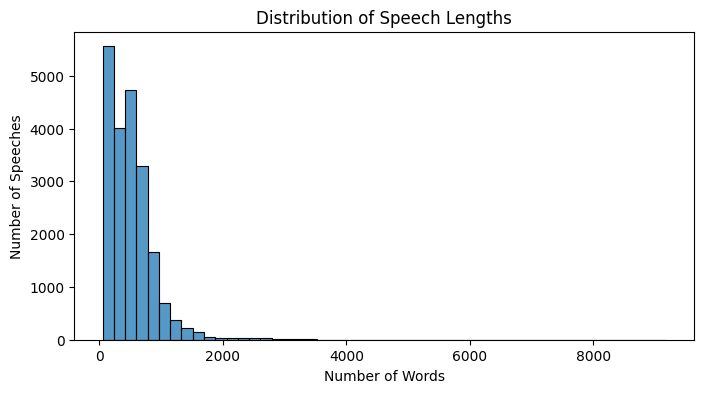

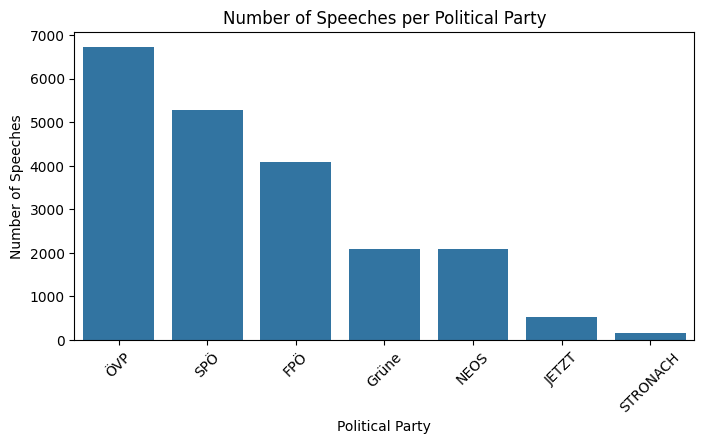

Vocabulary size: 325694
Average speech length: 495.70 words
Median speech length: 447.00 words


In [7]:
# Exploratory Data Analysis

# 1. Distribution of speech lengths
plt.figure(figsize=(8,4))
sns.histplot(df_all['speech_length'], bins=50)
plt.title('Distribution of Speech Lengths')
plt.xlabel('Number of Words')
plt.ylabel('Number of Speeches')
plt.show()

# 2. Distribution of speeches by political party
plt.figure(figsize=(8,4))
party_counts = df_all['Speaker_party'].value_counts()
sns.barplot(x=party_counts.index, y=party_counts.values)
plt.title('Number of Speeches per Political Party')
plt.xlabel('Political Party')
plt.ylabel('Number of Speeches')
plt.xticks(rotation=45)
plt.show()

# 3. Basic text statistics
vocab = set(' '.join(df_all['text']).split())
vocab_size = len(vocab)
avg_speech_length = df_all['speech_length'].mean()
median_speech_length = df_all['speech_length'].median()
print(f"Vocabulary size: {vocab_size}")
print(f"Average speech length: {avg_speech_length:.2f} words")
print(f"Median speech length: {median_speech_length:.2f} words")

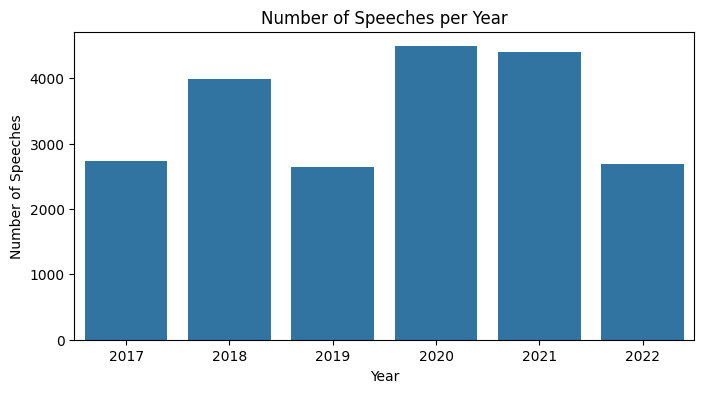

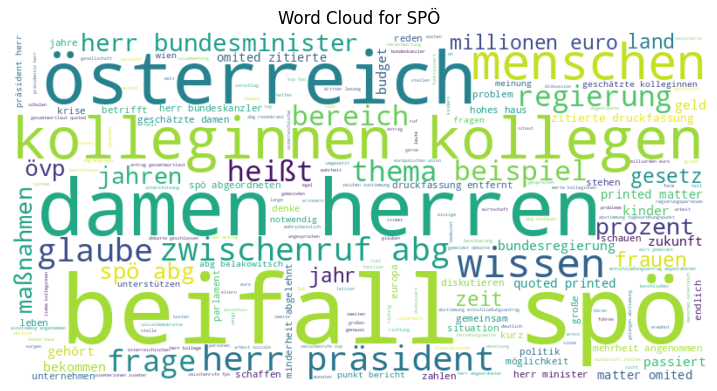

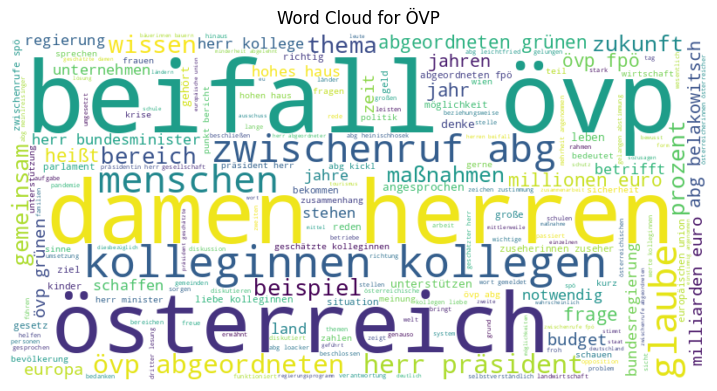

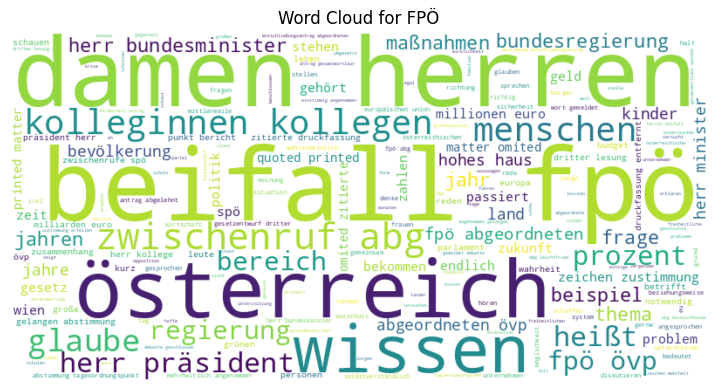

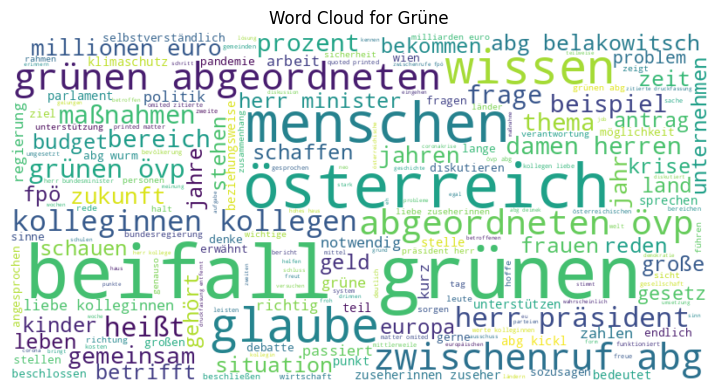

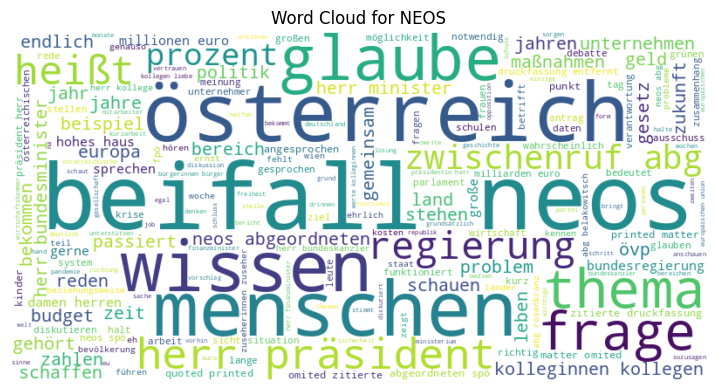

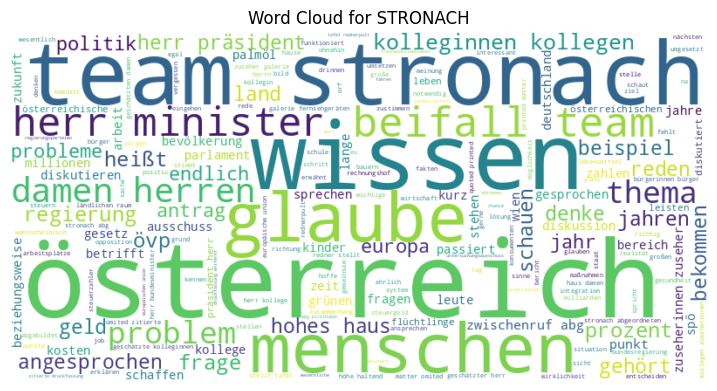

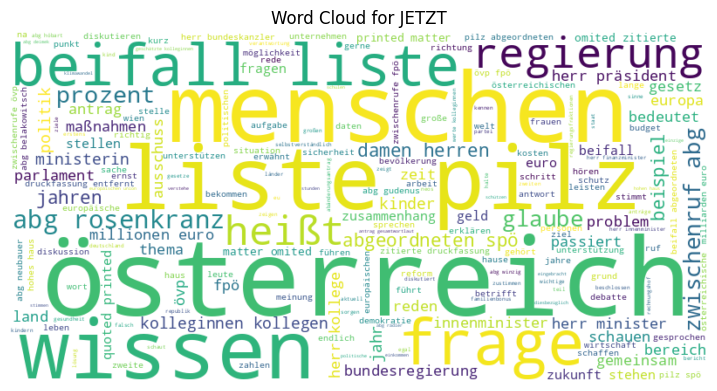

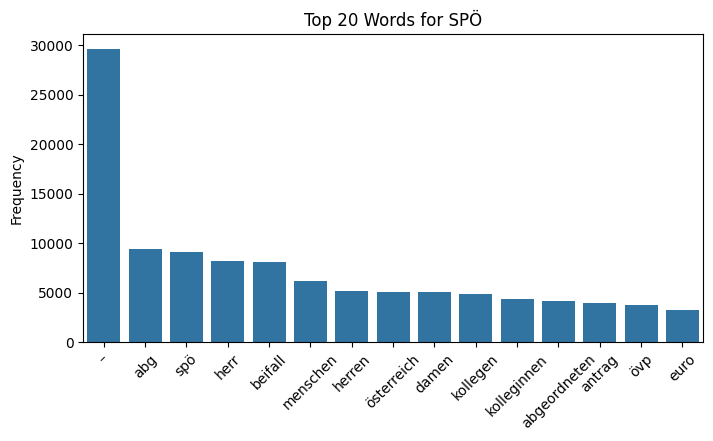

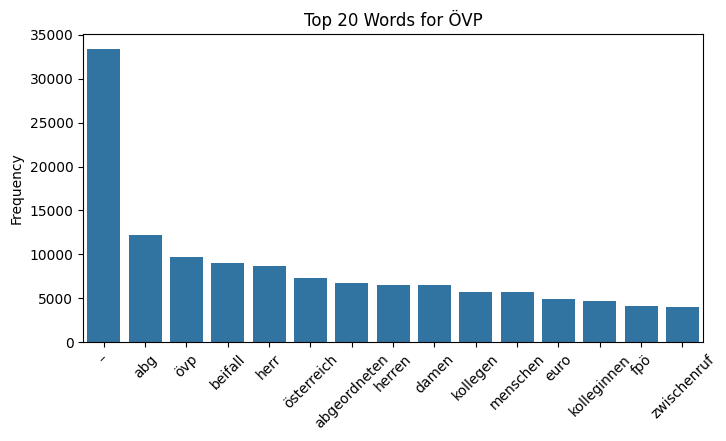

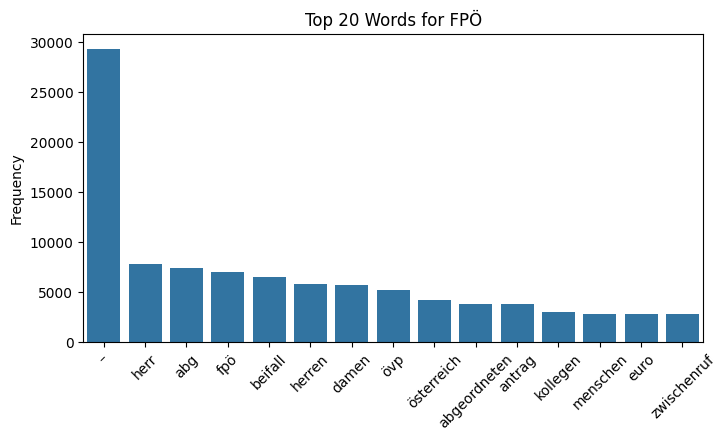

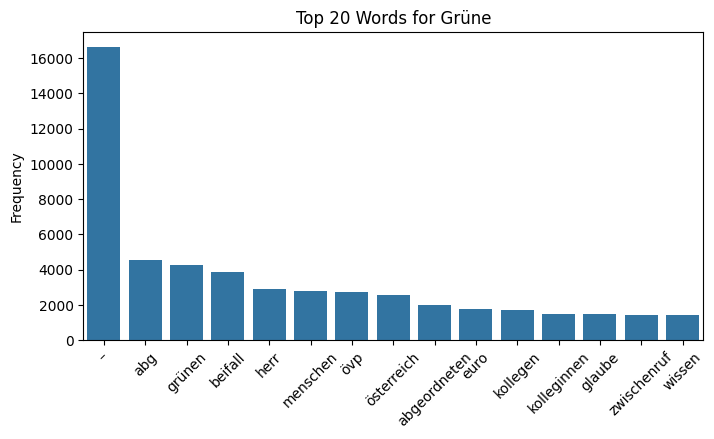

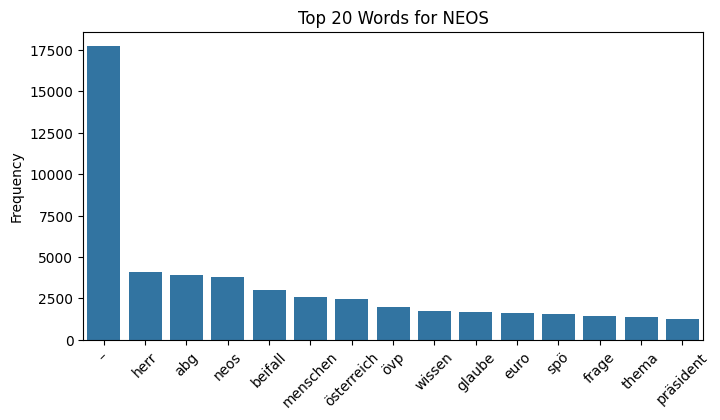

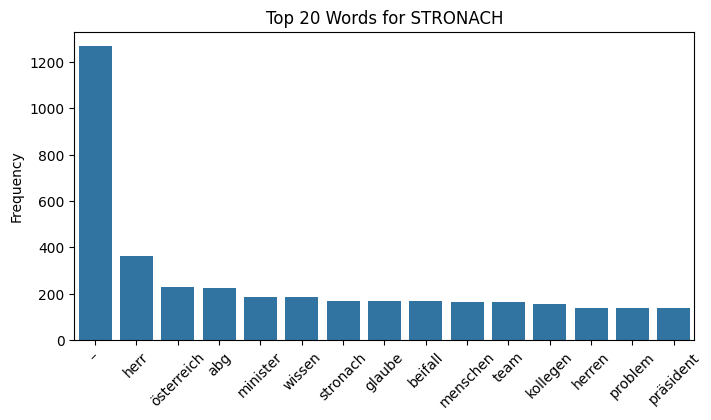

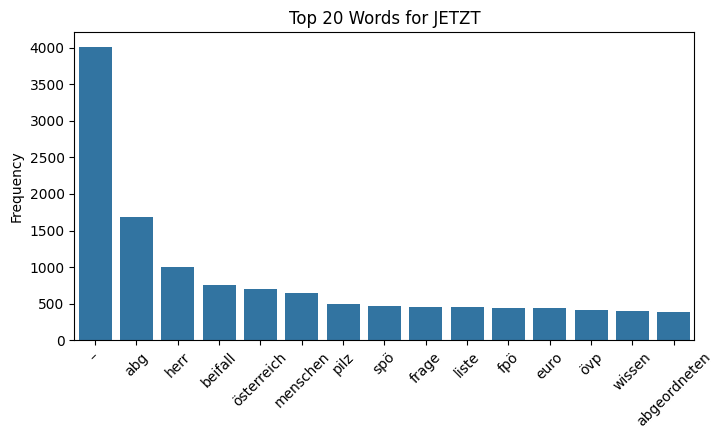

In [8]:
# 4. Temporal patterns (speeches per year)
df_all['year'] = pd.to_datetime(df_all['Date'], errors='coerce').dt.year
plt.figure(figsize=(8,4))
year_counts = df_all['year'].value_counts().sort_index()
sns.barplot(x=year_counts.index, y=year_counts.values)
plt.title('Number of Speeches per Year')
plt.xlabel('Year')
plt.ylabel('Number of Speeches')
plt.show()

# 5. Word clouds for each party
parties = df_all['Speaker_party'].unique()
for party in parties:
    party_text = ' '.join(df_all[df_all['Speaker_party'] == party]['processed_text'])
    if len(party_text) > 0:
        wordcloud = WordCloud(width=800, height=400, background_color='white').generate(party_text)
        plt.figure(figsize=(9,5))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'Word Cloud for {party}')
        plt.show()

# 6. Frequency distributions for top words per party
for party in parties:
    party_text = ' '.join(df_all[df_all['Speaker_party'] == party]['processed_text'])
    words = party_text.split()
    word_freq = Counter(words)
    most_common = word_freq.most_common(15)
    words, freqs = zip(*most_common)
    plt.figure(figsize=(8,4))
    sns.barplot(x=list(words), y=list(freqs))
    plt.title(f'Top 20 Words for {party}')
    plt.xticks(rotation=45)
    plt.ylabel('Frequency')
    plt.show()

### 2.2 Model Training and Comparison (10 points)

#### 2.2.1 Task A: Political Party Prediction
- Target: Multi-class classification of political party affiliation
- Hypothesis: Different parties use distinct vocabulary and rhetorical patterns
- Base model: Use a small pre-trained generative language model (e.g. Qwen, Gemma,
Llama ...)
- Features: Raw speech text (no manual feature engineering)

In [9]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

df_all['Speaker_birth'] = pd.to_numeric(df_all['Speaker_birth'], errors='coerce')

raw_dataset = Dataset.from_pandas(df_all)
raw_dataset = raw_dataset.shuffle(seed=42)

# Split: 70% train, 15% validation, 15% test
split_1 = raw_dataset.train_test_split(test_size=0.30, seed=42)
train_ds = split_1["train"]
temp_ds = split_1["test"]

split_2 = temp_ds.train_test_split(test_size=0.5, seed=42)
val_ds = split_2["train"]
test_ds = split_2["test"]

print(f"📚 Training samples: {len(train_ds)}")
print(f"🔎 Validation samples: {len(val_ds)}")
print(f"🧪 Test sample: {len(test_ds)}")

📚 Training samples: 14673
🔎 Validation samples: 3144
🧪 Test sample: 3145


In [10]:
model_name = "Qwen/Qwen3-0.6B"
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"🔧 Loading Qwen 3 model: {model_name}")
print(f"💻 Device: {device}")

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Load Qwen 3 model (full precision)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto" if torch.cuda.is_available() else None,
)

print("✅ Qwen 3 model and tokenizer loaded successfully!")
print(f"📊 Model parameters: {model.num_parameters():,}")
print(f"🔥 Model size: Only 0.6B parameters - perfect for education!")

🔧 Loading Qwen 3 model: Qwen/Qwen3-0.6B
💻 Device: cuda
✅ Qwen 3 model and tokenizer loaded successfully!
📊 Model parameters: 596,049,920
🔥 Model size: Only 0.6B parameters - perfect for education!


In [11]:
print("\n📏 SECTION 3: BASELINE EVALUATION")
print("-" * 40)

def generate_prediction(text, model, tokenizer):
    """Generate IPC code prediction using the base Qwen 3 model with chat template"""
    # Create messages in the format expected by Qwen 3
    messages = [
    {
        "role": "user",
        "content": f"""Analyze this Austrian parliamentary speech and predict the speaker's party affiliation.

        Parties to choose from: {parties}

        Speech text:
        {text[:1000]}

        Your answer (party name only): """
    }
]


    # Apply chat template with thinking disabled for consistency
    formatted_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False  # Disable for consistency with training
    )

    model_inputs = tokenizer([formatted_text], return_tensors="pt", max_length=512, truncation=True).to(model.device)


    # Generate prediction with proper stopping
    with torch.inference_mode():
        generated_ids = model.generate(
            **model_inputs,
            max_new_tokens=50,
            temperature=0.1,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,  # Ensure EOS token stops generation
        )

    # Extract only the new tokens
    output_ids = generated_ids[0][len(model_inputs.input_ids[0]):].tolist()

    # Decode the response and remove EOS token if present
    content = tokenizer.decode(output_ids, skip_special_tokens=True).strip()

    return content

def evaluate_model_predictions(model, model_name, eval_dataset, tokenizer, num_samples=None):
    """Evaluate model predictions on test set"""

    # Use all samples for evaluation since we have a small dataset
    if num_samples is None:
        num_samples = len(eval_dataset)

    predictions = []
    true_labels = []

    print(f"\n🔍 Evaluating {model_name} on {num_samples} samples...")

    for i in range(min(num_samples, len(eval_dataset))):
        sample = eval_dataset[i]


        prediction = generate_prediction(sample['text'], model, tokenizer)

        predictions.append(prediction)
        true_labels.append(sample['Speaker_party'])

        # Show progress
        if (i + 1) % 10 == 0:
            print(f"   Processed {i + 1}/{num_samples} samples...")

        if i < 3:  # Show first few examples
            print(f"   Example {i+1}:")
            print(f"      True: {sample['Speaker_party']}")
            print(f"      Pred: {prediction}")

    return predictions, true_labels

# Test baseline model on a few samples
print("🔍 Testing baseline Qwen 3 model performance:")
for i in range(3):
    sample = test_ds[i]
    prediction = generate_prediction(sample["text"], model, tokenizer)
    print(f"\n📄 Sample {i+1}:")
    print(f"   True Speaker_party: {sample['Speaker_party']}")
    print(f"   Predicted: {prediction}")

# Evaluate both models
results = {}

# Base model evaluation
print("📏 Evaluating Base Qwen 3 Model...")
base_preds, true_labels = evaluate_model_predictions(
    model, "Base Qwen 3", test_ds, tokenizer
)
results["Base Qwen 3"] = base_preds



📏 SECTION 3: BASELINE EVALUATION
----------------------------------------
🔍 Testing baseline Qwen 3 model performance:

📄 Sample 1:
   True Speaker_party: SPÖ
   Predicted: ÖVP

📄 Sample 2:
   True Speaker_party: JETZT
   Predicted: ÖVP

📄 Sample 3:
   True Speaker_party: ÖVP
   Predicted: Grüne
📏 Evaluating Base Qwen 3 Model...

🔍 Evaluating Base Qwen 3 on 3145 samples...
   Example 1:
      True: SPÖ
      Pred: ÖVP
   Example 2:
      True: JETZT
      Pred: ÖVP
   Example 3:
      True: ÖVP
      Pred: Grüne
   Processed 10/3145 samples...
   Processed 20/3145 samples...
   Processed 30/3145 samples...
   Processed 40/3145 samples...
   Processed 50/3145 samples...
   Processed 60/3145 samples...
   Processed 70/3145 samples...
   Processed 80/3145 samples...
   Processed 90/3145 samples...
   Processed 100/3145 samples...
   Processed 110/3145 samples...
   Processed 120/3145 samples...
   Processed 130/3145 samples...
   Processed 140/3145 samples...
   Processed 150/3145 sample

In [12]:

# ============================================================================
# SECTION 4: INSTRUCTION FINE-TUNING DATASET PREPARATION
# ============================================================================


def prepare_instruction_dataset(dataset, tokenizer, max_length=512):  # Reduced max_length
    """Prepare dataset for instruction fine-tuning with Qwen chat template format"""

    # Convert dataset to pandas for easier manipulation if needed
    if hasattr(dataset, 'to_pandas'):
        df = dataset.to_pandas()
    else:
        df = pd.DataFrame(dataset)

    # Prepare instruction data
    formatted_texts = []

    print(f"🔄 Preparing {len(df)} conversation examples...")

    for _, row in df.iterrows():
        # Create instruction-following format using Qwen chat template
        messages = [
            {
        "role": "user",
        "content": f"""Analyze this Austrian parliamentary speech and predict the speaker's party affiliation.

        Parties to choose from: {parties}

        Speech text:
        {row["text"][:1000]}

        Your answer (party name only): """
    },
    {
                "role": "assistant",
                "content": row["Speaker_party"] + tokenizer.eos_token  # ADD EOS TOKEN HERE
    }
        ]

        # Apply chat template
        formatted_text = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=False,
            enable_thinking=False  # Disable thinking for training to avoid complexity
        )
        formatted_texts.append(formatted_text)

    print(formatted_texts[0])

    # Tokenize all texts with proper padding and truncation
    print(f"🔄 Tokenizing {len(formatted_texts)} samples...")

    tokenized_data = tokenizer(
        formatted_texts,
        truncation=True,
        padding=True,  # Enable padding
        max_length=max_length,
        return_tensors="pt",
        return_attention_mask=True,
    )

    # Convert to lists for Dataset creation
    tokenized_dict = {
        "input_ids": tokenized_data["input_ids"].tolist(),
        "attention_mask": tokenized_data["attention_mask"].tolist(),
    }

    # Add labels (copy of input_ids for causal LM) with proper masking
    labels = tokenized_data["input_ids"].clone()
    # Set padding tokens to -100 so they're ignored in loss calculation
    labels[tokenized_data["input_ids"] == tokenizer.pad_token_id] = -100
    tokenized_dict["labels"] = labels.tolist()

    # Convert to Dataset
    final_dataset = Dataset.from_dict(tokenized_dict)

    return final_dataset

# Prepare instruction datasets
print("🔄 Preparing instruction fine-tuning datasets...")
print("💡 Using shorter sequences (512 tokens) and proper padding for stable training...")
print("🔚 IMPORTANT: Adding EOS tokens to teach the model when to stop generating!")
inst_train_ds = prepare_instruction_dataset(train_ds, tokenizer)
inst_val_ds = prepare_instruction_dataset(val_ds, tokenizer)

print("✅ Instruction datasets prepared with chat template format")
print(f"📊 Training samples: {len(inst_train_ds)}")
print(f"📊 Evaluation samples: {len(inst_val_ds)}")


🔄 Preparing instruction fine-tuning datasets...
💡 Using shorter sequences (512 tokens) and proper padding for stable training...
🔚 IMPORTANT: Adding EOS tokens to teach the model when to stop generating!
🔄 Preparing 14673 conversation examples...
<|im_start|>user
Analyze this Austrian parliamentary speech and predict the speaker's party affiliation.

        Parties to choose from: ['SPÖ' 'ÖVP' 'FPÖ' 'Grüne' 'NEOS' 'STRONACH' 'JETZT']

        Speech text:
        Zu Wort ist dazu nun niemand mehr gemeldet. Die Debatte ist geschlossen. Wünscht die Berichterstattung ein Schlusswort? – Das ist nicht der Fall. Ich darf wie vereinbart die Abstimmungen an das Ende der Verhandlungen über die Vorlagen des Ausschusses für Arbeit und Soziales legen. [[17:54:04]] 16. Punkt Bericht des Ausschusses für Arbeit und Soziales über den Antrag 1437/A(E) der Abgeordneten Mag. Christian Drobits, Kolleginnen und Kollegen betreffend „Datensicherheit sowie Daten- und Geschäftsgeheimnisschutz im Homeoffice“ (

In [13]:


# ============================================================================
# SECTION 5: LORA CONFIGURATION AND TRAINING SETUP
# ============================================================================


# Setup LoRA for efficient fine-tuning
lora_config = LoraConfig(
    # Specifies the task type - CAUSAL_LM indicates we're doing causal language modeling
    # where the model predicts the next token given previous tokens
    task_type=TaskType.CAUSAL_LM,

    # Set to False during training, True during inference
    # Controls whether LoRA adapters are active (False = training mode)
    inference_mode=False,

    # Rank of the low-rank decomposition matrices (A and B)
    # Lower values (4-16) = fewer parameters, faster training, less expressiveness
    # Higher values (32-64) = more parameters, slower training, more expressiveness
    # 16 is a good balance between efficiency and performance
    r=16,

    # Scaling factor that controls the magnitude of LoRA adaptations
    # Formula: LoRA_output = (alpha/r) * B * A * input
    # Higher alpha = stronger adaptation, lower alpha = weaker adaptation
    # Typically set to 2*r (32 for r=16) for optimal performance
    lora_alpha=32,

    # Dropout probability applied to LoRA layers for regularization
    # Helps prevent overfitting by randomly setting some neurons to zero
    # 0.1 (10%) is a common choice, can range from 0.0 to 0.3
    lora_dropout=0.1,

    # List of module names where LoRA adapters will be inserted
    # These target the key components of transformer attention and feed-forward layers:
    # - q_proj, k_proj, v_proj: Query, Key, Value projections in self-attention
    # - o_proj: Output projection after attention
    # - gate_proj, up_proj, down_proj: Components of the MLP/feed-forward network
    # Targeting these layers captures most of the model's learning capacity
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]
)

# Create LoRA model for instruction tuning
print("🔧 Creating LoRA model...")
inst_model = get_peft_model(model, lora_config)
inst_model.print_trainable_parameters()

# Training arguments for instruction tuning (optimized for sample data)
inst_training_args = TrainingArguments(
    output_dir="./instruction_results",
    num_train_epochs=2,  # Fewer epochs for sample data
    per_device_train_batch_size=2,  # Smaller batch size for stability
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,  # Increase to maintain effective batch size
    warmup_steps=50,  # Fewer warmup steps
    learning_rate=1e-4,  # Lower learning rate for stability
    fp16=True,
    logging_steps=10,  # More frequent logging for smaller dataset
    logging_dir=None,  # Disable tensorboard logging
    eval_strategy="steps",
    eval_steps=50,  # Less frequent evaluation for stability
    save_strategy="steps",
    save_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to=[],  # Disable all external logging (wandb, tensorboard, etc.)
    remove_unused_columns=False,
    dataloader_pin_memory=False,  # Can help with smaller datasets
    disable_tqdm=False,  # Keep progress bars for educational purposes
    max_grad_norm=1.0,  # Gradient clipping for stability
    dataloader_drop_last=True,  # Drop incomplete batches
)

# Data collator for language modeling with proper padding
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False,  # We're doing causal LM, not masked LM
    pad_to_multiple_of=8,
    return_tensors="pt",
)

print("✅ LoRA configuration and training setup completed")

🔧 Creating LoRA model...
trainable params: 10,092,544 || all params: 606,142,464 || trainable%: 1.6650
✅ LoRA configuration and training setup completed


In [14]:

# ============================================================================
# SECTION 6: INSTRUCTION FINE-TUNING
# ============================================================================


# Create trainer for instruction tuning
inst_trainer = Trainer(
    model=inst_model,
    args=inst_training_args,
    train_dataset=inst_train_ds,
    eval_dataset=inst_val_ds,
    data_collator=data_collator,
)

print("🎯 Starting Instruction fine-tuning of Qwen 3...")
print("⏱️  This may take a while depending on your hardware...")

# Train the model
training_output = inst_trainer.train()

print("✅ Instruction fine-tuning completed!")
print(f"📊 Final training loss: {training_output.training_loss:.4f}")

# Save the fine-tuned model
print("💾 Saving fine-tuned model...")
inst_trainer.save_model("./qwen3_ipc_finetuned")
tokenizer.save_pretrained("./qwen3_ipc_finetuned")

No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


🎯 Starting Instruction fine-tuning of Qwen 3...
⏱️  This may take a while depending on your hardware...


Step,Training Loss,Validation Loss
50,2.187800,2.150781
100,2.008300,1.979080
150,1.889200,1.911247
200,1.865200,1.869425
250,1.817500,1.839020
300,1.824800,1.816896
350,1.807000,1.795947
400,1.770200,1.779139
450,1.794400,1.767852
500,1.764600,1.755117


✅ Instruction fine-tuning completed!
📊 Final training loss: 1.7487
💾 Saving fine-tuned model...


('./qwen3_ipc_finetuned/tokenizer_config.json',
 './qwen3_ipc_finetuned/special_tokens_map.json',
 './qwen3_ipc_finetuned/chat_template.jinja',
 './qwen3_ipc_finetuned/vocab.json',
 './qwen3_ipc_finetuned/merges.txt',
 './qwen3_ipc_finetuned/added_tokens.json',
 './qwen3_ipc_finetuned/tokenizer.json')

In [15]:

print("\n📊 SECTION 7: MODEL EVALUATION")
print("-" * 40)

# Fine-tuned model evaluation
print("📏 Evaluating Fine-tuned Qwen 3 Model...")
finetuned_preds, _ = evaluate_model_predictions(
    inst_model, "Fine-tuned Qwen 3", test_ds, tokenizer
)
results["Fine-tuned Qwen 3"] = finetuned_preds



📊 SECTION 7: MODEL EVALUATION
----------------------------------------
📏 Evaluating Fine-tuned Qwen 3 Model...

🔍 Evaluating Fine-tuned Qwen 3 on 3145 samples...
   Example 1:
      True: SPÖ
      Pred: SPÖ
   Example 2:
      True: JETZT
      Pred: ÖVP
   Example 3:
      True: ÖVP
      Pred: ÖVP
   Processed 10/3145 samples...
   Processed 20/3145 samples...
   Processed 30/3145 samples...
   Processed 40/3145 samples...
   Processed 50/3145 samples...
   Processed 60/3145 samples...
   Processed 70/3145 samples...
   Processed 80/3145 samples...
   Processed 90/3145 samples...
   Processed 100/3145 samples...
   Processed 110/3145 samples...
   Processed 120/3145 samples...
   Processed 130/3145 samples...
   Processed 140/3145 samples...
   Processed 150/3145 samples...
   Processed 160/3145 samples...
   Processed 170/3145 samples...
   Processed 180/3145 samples...
   Processed 190/3145 samples...
   Processed 200/3145 samples...
   Processed 210/3145 samples...
   Processed 

🔄 Recalculating metrics for single-label classification...

🤖 Base Qwen 3:
   📊 Accuracy: 0.290
   📊 Macro Precision: 0.383
   📊 Macro Recall: 0.200
   📊 Macro F1 Score: 0.143

🤖 Fine-tuned Qwen 3:
   📊 Accuracy: 0.562
   📊 Macro Precision: 0.693
   📊 Macro Recall: 0.425
   📊 Macro F1 Score: 0.480


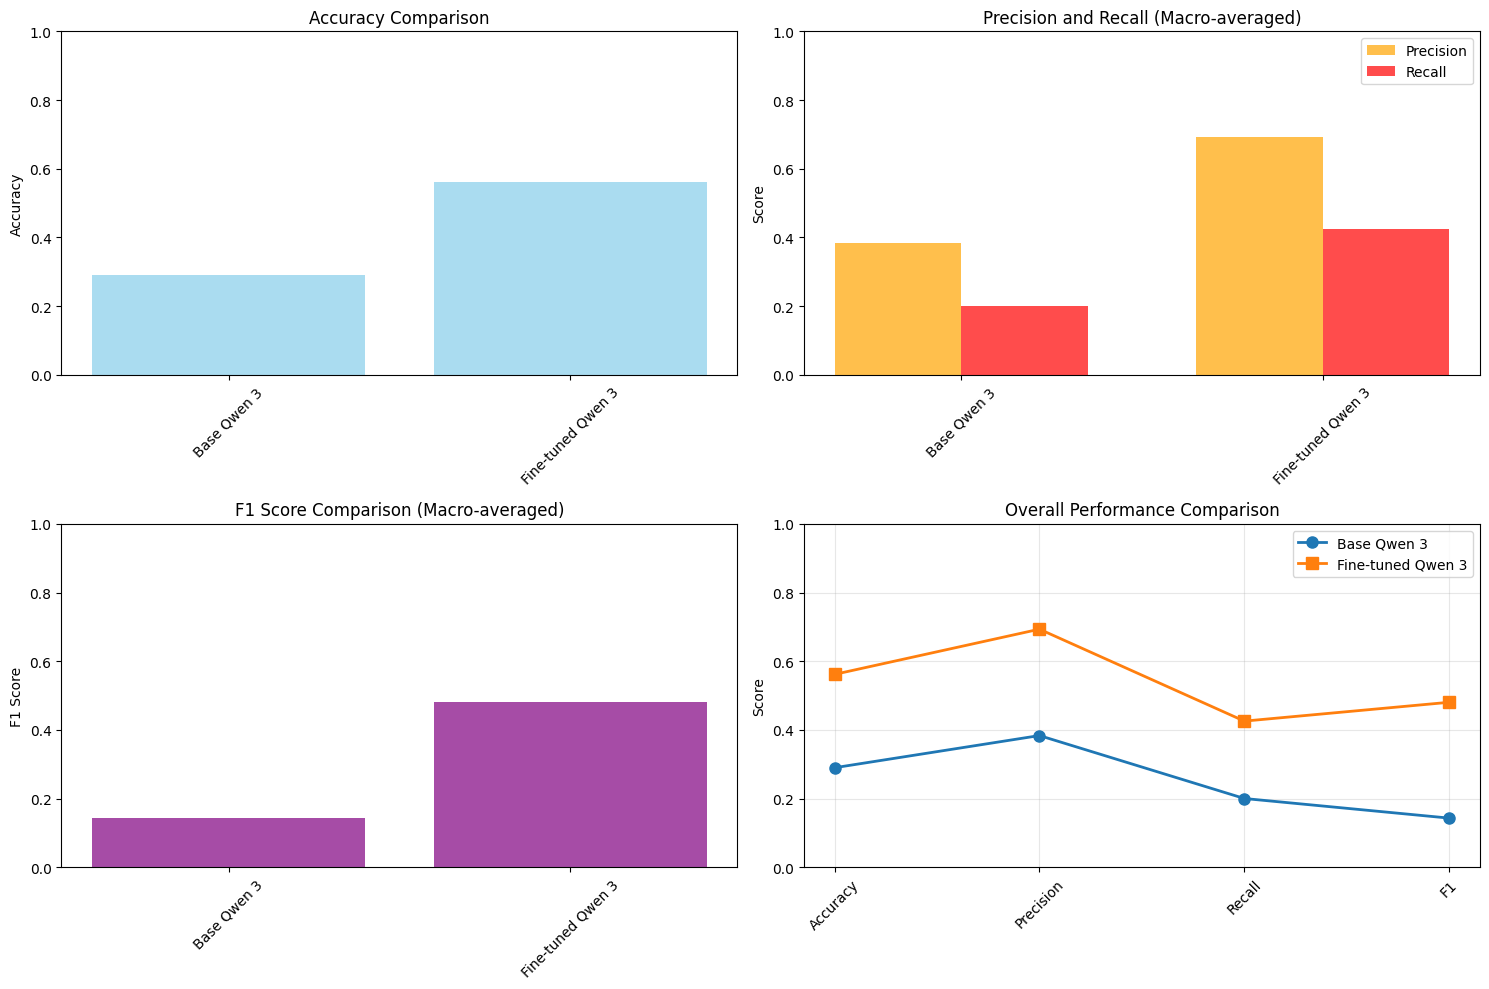

In [16]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import numpy as np

def calculate_proper_metrics(predictions, true_labels):
    """Calculate proper metrics for single-label classification"""
    
    # Clean predictions to extract party names
    cleaned_predictions = []
    for pred in predictions:
        pred_clean = pred.strip().upper()
        found_party = "UNKNOWN"  # Initialize before the loop
        for party in parties:
            if party.upper() in pred_clean:
                found_party = party
                break
        cleaned_predictions.append(found_party)
    
    # Calculate accuracy
    accuracy = accuracy_score(true_labels, cleaned_predictions)
    
    # Calculate per-class precision, recall, f1 (macro-averaged)
    precision, recall, f1, _ = precision_recall_fscore_support(
        true_labels, cleaned_predictions, average='macro', zero_division=0
    )
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

# Recalculate metrics properly
print("🔄 Recalculating metrics for single-label classification...")

metrics_summary = {}
for model_name, preds in results.items():
    metrics = calculate_proper_metrics(preds, true_labels)
    metrics_summary[model_name] = metrics
    
    print(f"\n🤖 {model_name}:")
    print(f"   📊 Accuracy: {metrics['accuracy']:.3f}")
    print(f"   📊 Macro Precision: {metrics['precision']:.3f}")
    print(f"   📊 Macro Recall: {metrics['recall']:.3f}")
    print(f"   📊 Macro F1 Score: {metrics['f1']:.3f}")

# Create visualization with corrected metrics (3 plots instead of 4)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

model_names = list(results.keys())
accuracies = [metrics_summary[name]['accuracy'] for name in model_names]
precisions = [metrics_summary[name]['precision'] for name in model_names]
recalls = [metrics_summary[name]['recall'] for name in model_names]
f1_scores = [metrics_summary[name]['f1'] for name in model_names]

# Accuracy comparison
axes[0, 0].bar(model_names, accuracies, alpha=0.7, color='skyblue')
axes[0, 0].set_title('Accuracy Comparison')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].set_ylim(0, 1.0)

# Precision and Recall
x = np.arange(len(model_names))
width = 0.35
axes[0, 1].bar(x - width/2, precisions, width, label='Precision', alpha=0.7, color='orange')
axes[0, 1].bar(x + width/2, recalls, width, label='Recall', alpha=0.7, color='red')
axes[0, 1].set_title('Precision and Recall (Macro-averaged)')
axes[0, 1].set_ylabel('Score')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(model_names, rotation=45)
axes[0, 1].legend()
axes[0, 1].set_ylim(0, 1.0)

# F1 Score comparison
axes[1, 0].bar(model_names, f1_scores, alpha=0.7, color='purple')
axes[1, 0].set_title('F1 Score Comparison (Macro-averaged)')
axes[1, 0].set_ylabel('F1 Score')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].set_ylim(0, 1.0)

# Overall performance comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
base_scores = [accuracies[0], precisions[0], recalls[0], f1_scores[0]]
ft_scores = [accuracies[1], precisions[1], recalls[1], f1_scores[1]]

axes[1, 1].plot(metrics, base_scores, 'o-', label=model_names[0], linewidth=2, markersize=8)
axes[1, 1].plot(metrics, ft_scores, 's-', label=model_names[1], linewidth=2, markersize=8)
axes[1, 1].set_title('Overall Performance Comparison')
axes[1, 1].set_ylabel('Score')
axes[1, 1].legend()
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_ylim(0, 1.0)

plt.tight_layout()
plt.show()


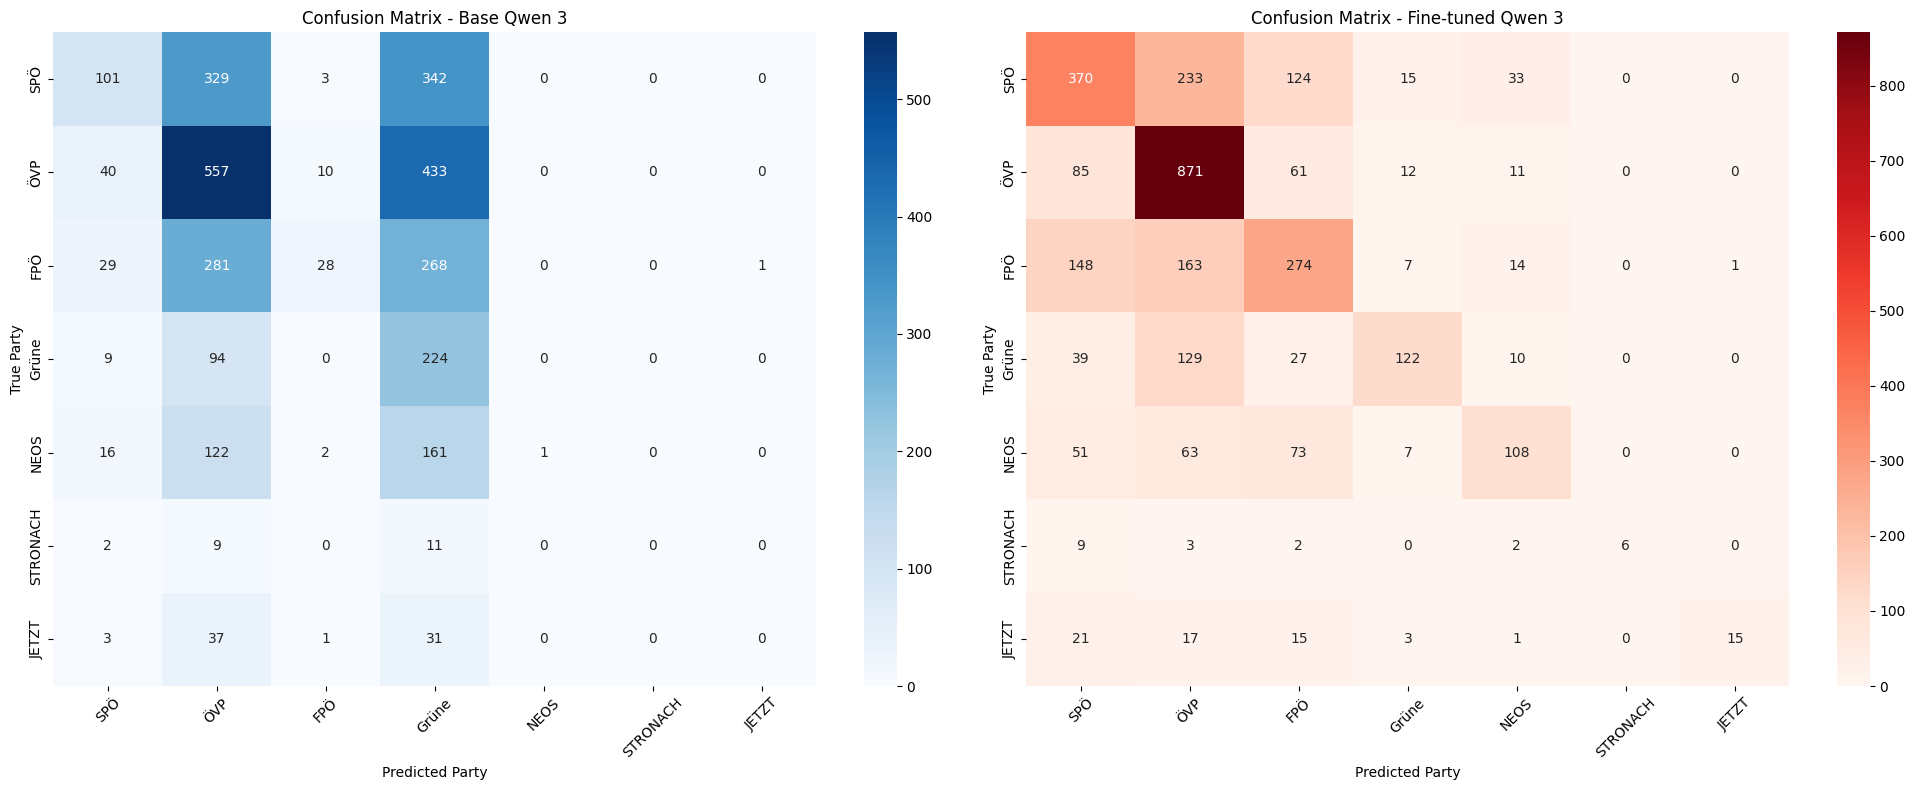

Base Model Accuracy: 0.290
Fine-tuned Model Accuracy: 0.562


In [17]:
#Include confusion matrices and classification reports
from sklearn.metrics import confusion_matrix

# Clean predictions for both models
base_cleaned_predictions = []
for pred in base_preds:
    pred_clean = pred.strip()
    found_party = "UNKNOWN"
    for party in parties:
        if party in pred_clean:
            found_party = party
            break
    base_cleaned_predictions.append(found_party)

ft_cleaned_predictions = []
for pred in finetuned_preds:
    pred_clean = pred.strip()
    found_party = "UNKNOWN"
    for party in parties:
        if party in pred_clean:
            found_party = party
            break
    ft_cleaned_predictions.append(found_party)

# Create confusion matrices
cm_base = confusion_matrix(true_labels, base_cleaned_predictions, labels=parties)
cm_ft = confusion_matrix(true_labels, ft_cleaned_predictions, labels=parties)

# Plot confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Base model confusion matrix
sns.heatmap(cm_base, 
            annot=True, 
            fmt='d',
            cmap='Blues',
            xticklabels=parties,
            yticklabels=parties,
            ax=axes[0])
axes[0].set_title('Confusion Matrix - Base Qwen 3')
axes[0].set_xlabel('Predicted Party')
axes[0].set_ylabel('True Party')
axes[0].tick_params(axis='x', rotation=45)

# Fine-tuned model confusion matrix
sns.heatmap(cm_ft, 
            annot=True, 
            fmt='d',
            cmap='Reds',
            xticklabels=parties,
            yticklabels=parties,
            ax=axes[1])
axes[1].set_title('Confusion Matrix - Fine-tuned Qwen 3')
axes[1].set_xlabel('Predicted Party')
axes[1].set_ylabel('True Party')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Print accuracies
base_accuracy = np.trace(cm_base) / np.sum(cm_base)
ft_accuracy = np.trace(cm_ft) / np.sum(cm_ft)
print(f"Base Model Accuracy: {base_accuracy:.3f}")
print(f"Fine-tuned Model Accuracy: {ft_accuracy:.3f}")


In [18]:
# delete cache and training args
del inst_trainer
del inst_train_ds, inst_val_ds
del training_output
torch.cuda.empty_cache()
import gc
gc.collect()

print("🧹 Training memory freed. Only base and fine-tuned models remain.")


🧹 Training memory freed. Only base and fine-tuned models remain.


#### 2.2.2 Task B: Ideological Orientation Prediction
- Target: Multi-class classification (left/center/right etc)
- Hypothesis: Ideological positions manifest in language use and topic focus
- Base model: Same architecture as Task A
- Features: Raw speech text

In [19]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

raw_dataset = Dataset.from_pandas(df_all)
raw_dataset = raw_dataset.shuffle(seed=42)

# Split: 70% train, 15% validation, 15% test
split_1 = raw_dataset.train_test_split(test_size=0.30, seed=42)
train_ds = split_1["train"]
temp_ds = split_1["test"]

split_2 = temp_ds.train_test_split(test_size=0.5, seed=42)
val_ds = split_2["train"]
test_ds = split_2["test"]

print(f"📚 Training samples: {len(train_ds)}")
print(f"🔎 Validation samples: {len(val_ds)}")
print(f"🧪 Test sample: {len(test_ds)}")

📚 Training samples: 14673
🔎 Validation samples: 3144
🧪 Test sample: 3145


In [20]:
model_name = "Qwen/Qwen3-0.6B"
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"🔧 Loading Qwen 3 model: {model_name}")
print(f"💻 Device: {device}")

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Load Qwen 3 model (full precision)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto" if torch.cuda.is_available() else None,
)

print("✅ Qwen 3 model and tokenizer loaded successfully!")
print(f"📊 Model parameters: {model.num_parameters():,}")
print(f"🔥 Model size: Only 0.6B parameters - perfect for education!")

🔧 Loading Qwen 3 model: Qwen/Qwen3-0.6B
💻 Device: cuda
✅ Qwen 3 model and tokenizer loaded successfully!
📊 Model parameters: 596,049,920
🔥 Model size: Only 0.6B parameters - perfect for education!


In [21]:
orientation = list(df_all["Party_orientation"].unique())
print("\n📏 SECTION 3: BASELINE EVALUATION")
print("-" * 40)

def generate_prediction(text, model, tokenizer):
    """Generate IPC code prediction using the base Qwen 3 model with chat template"""
    # Create messages in the format expected by Qwen 3
    messages = [
    {
        "role": "user",
        "content": f"""Analyze this Austrian parliamentary speech and predict the political orientation.

        possible political orientations: {orientation}

        Speech text:
        {text[:1000]}

        Your answer (political orientation only): """
    }
]


    # Apply chat template with thinking disabled for consistency
    formatted_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False  # Disable for consistency with training
    )

    model_inputs = tokenizer([formatted_text], return_tensors="pt", max_length=512, truncation=True).to(model.device)


    # Generate prediction with proper stopping
    with torch.inference_mode():
        generated_ids = model.generate(
            **model_inputs,
            max_new_tokens=50,
            temperature=0.1,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,  # Ensure EOS token stops generation
        )

    # Extract only the new tokens
    output_ids = generated_ids[0][len(model_inputs.input_ids[0]):].tolist()

    # Decode the response and remove EOS token if present
    content = tokenizer.decode(output_ids, skip_special_tokens=True).strip()

    return content

def evaluate_model_predictions(model, model_name, eval_dataset, tokenizer, num_samples=None):
    """Evaluate model predictions on test set"""

    # Use all samples for evaluation since we have a small dataset
    if num_samples is None:
        num_samples = len(eval_dataset)

    predictions = []
    true_labels = []

    print(f"\n🔍 Evaluating {model_name} on {num_samples} samples...")

    for i in range(min(num_samples, len(eval_dataset))):
        sample = eval_dataset[i]


        prediction = generate_prediction(sample['text'], model, tokenizer)

        predictions.append(prediction)
        true_labels.append(sample['Party_orientation'])

        # Show progress
        if (i + 1) % 10 == 0:
            print(f"   Processed {i + 1}/{num_samples} samples...")

        if i < 3:  # Show first few examples
            print(f"   Example {i+1}:")
            print(f"      True: {sample['Party_orientation']}")
            print(f"      Pred: {prediction}")

    return predictions, true_labels

# Test baseline model on a few samples
print("🔍 Testing baseline Qwen 3 model performance:")
for i in range(3):
    sample = test_ds[i]
    prediction = generate_prediction(sample["text"], model, tokenizer)
    print(f"\n📄 Sample {i+1}:")
    print(f"   True orientation: {sample['Party_orientation']}")
    print(f"   Predicted: {prediction}")

# Evaluate both models
results = {}

# Base model evaluation
print("📏 Evaluating Base Qwen 3 Model...")
base_preds, true_labels = evaluate_model_predictions(
    model, "Base Qwen 3", test_ds, tokenizer
)
results["Base Qwen 3"] = base_preds


📏 SECTION 3: BASELINE EVALUATION
----------------------------------------
🔍 Testing baseline Qwen 3 model performance:

📄 Sample 1:
   True orientation: Mitte-links
   Predicted: Mitte-links

📄 Sample 2:
   True orientation: Mitte-links bis Links
   Predicted: Mitte-links

📄 Sample 3:
   True orientation: Mitte-rechts bis Rechts
   Predicted: Mitte-links
📏 Evaluating Base Qwen 3 Model...

🔍 Evaluating Base Qwen 3 on 3145 samples...
   Example 1:
      True: Mitte-links
      Pred: Mitte-links
   Example 2:
      True: Mitte-links bis Links
      Pred: Mitte-links
   Example 3:
      True: Mitte-rechts bis Rechts
      Pred: Mitte-links
   Processed 10/3145 samples...
   Processed 20/3145 samples...
   Processed 30/3145 samples...
   Processed 40/3145 samples...
   Processed 50/3145 samples...
   Processed 60/3145 samples...
   Processed 70/3145 samples...
   Processed 80/3145 samples...
   Processed 90/3145 samples...
   Processed 100/3145 samples...
   Processed 110/3145 samples...
 

In [22]:

# ============================================================================
# SECTION 4: INSTRUCTION FINE-TUNING DATASET PREPARATION
# ============================================================================


def prepare_instruction_dataset(dataset, tokenizer, max_length=512):  # Reduced max_length
    """Prepare dataset for instruction fine-tuning with Qwen chat template format"""

    # Convert dataset to pandas for easier manipulation if needed
    if hasattr(dataset, 'to_pandas'):
        df = dataset.to_pandas()
    else:
        df = pd.DataFrame(dataset)

    # Prepare instruction data
    formatted_texts = []

    print(f"🔄 Preparing {len(df)} conversation examples...")

    for _, row in df.iterrows():
        # Create instruction-following format using Qwen chat template
        messages = [
        {
        "role": "user",
        "content": f"""Analyze this Austrian parliamentary speech and predict the political orientation.

        possible political orientations: {orientation}

        Speech text:
        {text[:1000]}

        Your answer (political orientation only): """
    },
    {
                "role": "assistant",
                "content": row['Party_orientation'] + tokenizer.eos_token  # ADD EOS TOKEN HERE
    }
        ]

        # Apply chat template
        formatted_text = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=False,
            enable_thinking=False  # Disable thinking for training to avoid complexity
        )
        formatted_texts.append(formatted_text)

    print(formatted_texts[0])

    # Tokenize all texts with proper padding and truncation
    print(f"🔄 Tokenizing {len(formatted_texts)} samples...")

    tokenized_data = tokenizer(
        formatted_texts,
        truncation=True,
        padding=True,  # Enable padding
        max_length=max_length,
        return_tensors="pt",
        return_attention_mask=True,
    )

    # Convert to lists for Dataset creation
    tokenized_dict = {
        "input_ids": tokenized_data["input_ids"].tolist(),
        "attention_mask": tokenized_data["attention_mask"].tolist(),
    }

    # Add labels (copy of input_ids for causal LM) with proper masking
    labels = tokenized_data["input_ids"].clone()
    # Set padding tokens to -100 so they're ignored in loss calculation
    labels[tokenized_data["input_ids"] == tokenizer.pad_token_id] = -100
    tokenized_dict["labels"] = labels.tolist()

    # Convert to Dataset
    final_dataset = Dataset.from_dict(tokenized_dict)

    return final_dataset

# Prepare instruction datasets
print("🔄 Preparing instruction fine-tuning datasets...")
print("💡 Using shorter sequences (512 tokens) and proper padding for stable training...")
print("🔚 IMPORTANT: Adding EOS tokens to teach the model when to stop generating!")
inst_train_ds = prepare_instruction_dataset(train_ds, tokenizer)
inst_val_ds = prepare_instruction_dataset(val_ds, tokenizer)

print("✅ Instruction datasets prepared with chat template format")
print(f"📊 Training samples: {len(inst_train_ds)}")
print(f"📊 Evaluation samples: {len(inst_val_ds)}")


🔄 Preparing instruction fine-tuning datasets...
💡 Using shorter sequences (512 tokens) and proper padding for stable training...
🔚 IMPORTANT: Adding EOS tokens to teach the model when to stop generating!
🔄 Preparing 14673 conversation examples...
<|im_start|>user
Analyze this Austrian parliamentary speech and predict the political orientation.

        possible political orientations: ['Mitte-links', 'Mitte-rechts bis Rechts', 'Rechts bis extrem Rechts', 'Mitte-links bis Links', 'Mitte']

        Speech text:
        Wir kommen zur Abstimmung über den Antrag der Abgeordneten Taschner und Hamann, dem Unterrichtsausschuss zur Berichterstattung über die Regierungsvorlage 1696 der Beilagen eine Frist bis zum 11. Oktober 2022 zu setzen. Wer dafür ist, den bitte ich um ein Zeichen. – Das ist die Mehrheit, angenommen. Die nächste Sitzung des Nationalrates berufe ich für Dienstag, den 4. Oktober, um 8 Uhr, ein. Die Tagesordnung ist auf schriftlichem Wege ergangen. Weiters gebe ich bekannt, das

In [23]:
# ============================================================================
# SECTION 5: LORA CONFIGURATION AND TRAINING SETUP
# ============================================================================


# Setup LoRA for efficient fine-tuning
lora_config = LoraConfig(
    # Specifies the task type - CAUSAL_LM indicates we're doing causal language modeling
    # where the model predicts the next token given previous tokens
    task_type=TaskType.CAUSAL_LM,

    # Set to False during training, True during inference
    # Controls whether LoRA adapters are active (False = training mode)
    inference_mode=False,

    # Rank of the low-rank decomposition matrices (A and B)
    # Lower values (4-16) = fewer parameters, faster training, less expressiveness
    # Higher values (32-64) = more parameters, slower training, more expressiveness
    # 16 is a good balance between efficiency and performance
    r=32, #changed setup here

    # Scaling factor that controls the magnitude of LoRA adaptations
    # Formula: LoRA_output = (alpha/r) * B * A * input
    # Higher alpha = stronger adaptation, lower alpha = weaker adaptation
    # Typically set to 2*r (32 for r=16) for optimal performance
    lora_alpha=64, #changed setup here

    # Dropout probability applied to LoRA layers for regularization
    # Helps prevent overfitting by randomly setting some neurons to zero
    # 0.1 (10%) is a common choice, can range from 0.0 to 0.3
    lora_dropout=0.1,

    # List of module names where LoRA adapters will be inserted
    # These target the key components of transformer attention and feed-forward layers:
    # - q_proj, k_proj, v_proj: Query, Key, Value projections in self-attention
    # - o_proj: Output projection after attention
    # - gate_proj, up_proj, down_proj: Components of the MLP/feed-forward network
    # Targeting these layers captures most of the model's learning capacity
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]
)

# Create LoRA model for instruction tuning
print("🔧 Creating LoRA model...")
inst_model = get_peft_model(model, lora_config)
inst_model.print_trainable_parameters()

# Training arguments for instruction tuning (optimized for sample data)
inst_training_args = TrainingArguments(
    output_dir="./instruction_results_2",
    num_train_epochs=2,  # Fewer epochs for sample data
    per_device_train_batch_size=2,  # Smaller batch size for stability
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,  # Increase to maintain effective batch size
    warmup_steps=50,  # Fewer warmup steps
    learning_rate=1e-4,  # Lower learning rate for stability
    fp16=True,
    logging_steps=10,  # More frequent logging for smaller dataset
    logging_dir=None,  # Disable tensorboard logging
    eval_strategy="steps",
    eval_steps=50,  # Less frequent evaluation for stability
    save_strategy="steps",
    save_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to=[],  # Disable all external logging (wandb, tensorboard, etc.)
    remove_unused_columns=False,
    dataloader_pin_memory=False,  # Can help with smaller datasets
    disable_tqdm=False,  # Keep progress bars for educational purposes
    max_grad_norm=1.0,  # Gradient clipping for stability
    dataloader_drop_last=True,  # Drop incomplete batches
)

# Data collator for language modeling with proper padding
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False,  # We're doing causal LM, not masked LM
    pad_to_multiple_of=8,
    return_tensors="pt",
)

print("✅ LoRA configuration and training setup completed")

🔧 Creating LoRA model...
trainable params: 20,185,088 || all params: 616,235,008 || trainable%: 3.2756
✅ LoRA configuration and training setup completed


In [25]:

# ============================================================================
# SECTION 6: INSTRUCTION FINE-TUNING
# ============================================================================


# Create trainer for instruction tuning
inst_trainer = Trainer(
    model=inst_model,
    args=inst_training_args,
    train_dataset=inst_train_ds,
    eval_dataset=inst_val_ds,
    data_collator=data_collator,
)

print("🎯 Starting Instruction fine-tuning of Qwen 3...")
print("⏱️  This may take a while depending on your hardware...")

# Train the model
training_output = inst_trainer.train()

print("✅ Instruction fine-tuning completed!")
print(f"📊 Final training loss: {training_output.training_loss:.4f}")

# Save the fine-tuned model
print("💾 Saving fine-tuned model...")
inst_trainer.save_model("./qwen3_ipc_finetuned_2")
tokenizer.save_pretrained("./qwen3_ipc_finetuned_2")

No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


🎯 Starting Instruction fine-tuning of Qwen 3...
⏱️  This may take a while depending on your hardware...


Step,Training Loss,Validation Loss
50,0.006900,0.008076
100,0.006000,0.006432
150,0.006400,0.006123
200,0.006200,0.006332
250,0.005900,0.005802
300,0.006100,0.006193
350,0.006100,0.005817
400,0.006100,0.005886
450,0.005900,0.005783
500,0.006100,0.005936


IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



✅ Instruction fine-tuning completed!
📊 Final training loss: 0.0059
💾 Saving fine-tuned model...


('./qwen3_ipc_finetuned_2/tokenizer_config.json',
 './qwen3_ipc_finetuned_2/special_tokens_map.json',
 './qwen3_ipc_finetuned_2/chat_template.jinja',
 './qwen3_ipc_finetuned_2/vocab.json',
 './qwen3_ipc_finetuned_2/merges.txt',
 './qwen3_ipc_finetuned_2/added_tokens.json',
 './qwen3_ipc_finetuned_2/tokenizer.json')

In [26]:
print("\n📊 SECTION 7: MODEL EVALUATION")
print("-" * 40)

# Fine-tuned model evaluation
print("📏 Evaluating Fine-tuned Qwen 3_2 Model...")
finetuned_preds, _ = evaluate_model_predictions(
    inst_model, "Fine-tuned Qwen 3_2", test_ds, tokenizer
)
results["Fine-tuned Qwen 3_2"] = finetuned_preds


📊 SECTION 7: MODEL EVALUATION
----------------------------------------
📏 Evaluating Fine-tuned Qwen 3_2 Model...

🔍 Evaluating Fine-tuned Qwen 3_2 on 3145 samples...
   Example 1:
      True: Mitte-links
      Pred: Mitte-links
   Example 2:
      True: Mitte-links bis Links
      Pred: Mitte-links
   Example 3:
      True: Mitte-rechts bis Rechts
      Pred: Mitte-rechts bis Rechts
   Processed 10/3145 samples...
   Processed 20/3145 samples...
   Processed 30/3145 samples...
   Processed 40/3145 samples...
   Processed 50/3145 samples...
   Processed 60/3145 samples...
   Processed 70/3145 samples...
   Processed 80/3145 samples...
   Processed 90/3145 samples...
   Processed 100/3145 samples...
   Processed 110/3145 samples...
   Processed 120/3145 samples...
   Processed 130/3145 samples...
   Processed 140/3145 samples...
   Processed 150/3145 samples...
   Processed 160/3145 samples...
   Processed 170/3145 samples...
   Processed 180/3145 samples...
   Processed 190/3145 sample

🔄 Recalculating metrics for single-label classification...

🤖 Base Qwen 3:
   📊 Accuracy: 0.246
   📊 Macro Precision: 0.049
   📊 Macro Recall: 0.200
   📊 Macro F1 Score: 0.079

🤖 Fine-tuned Qwen 3_2:
   📊 Accuracy: 0.282
   📊 Macro Precision: 0.122
   📊 Macro Recall: 0.209
   📊 Macro F1 Score: 0.138


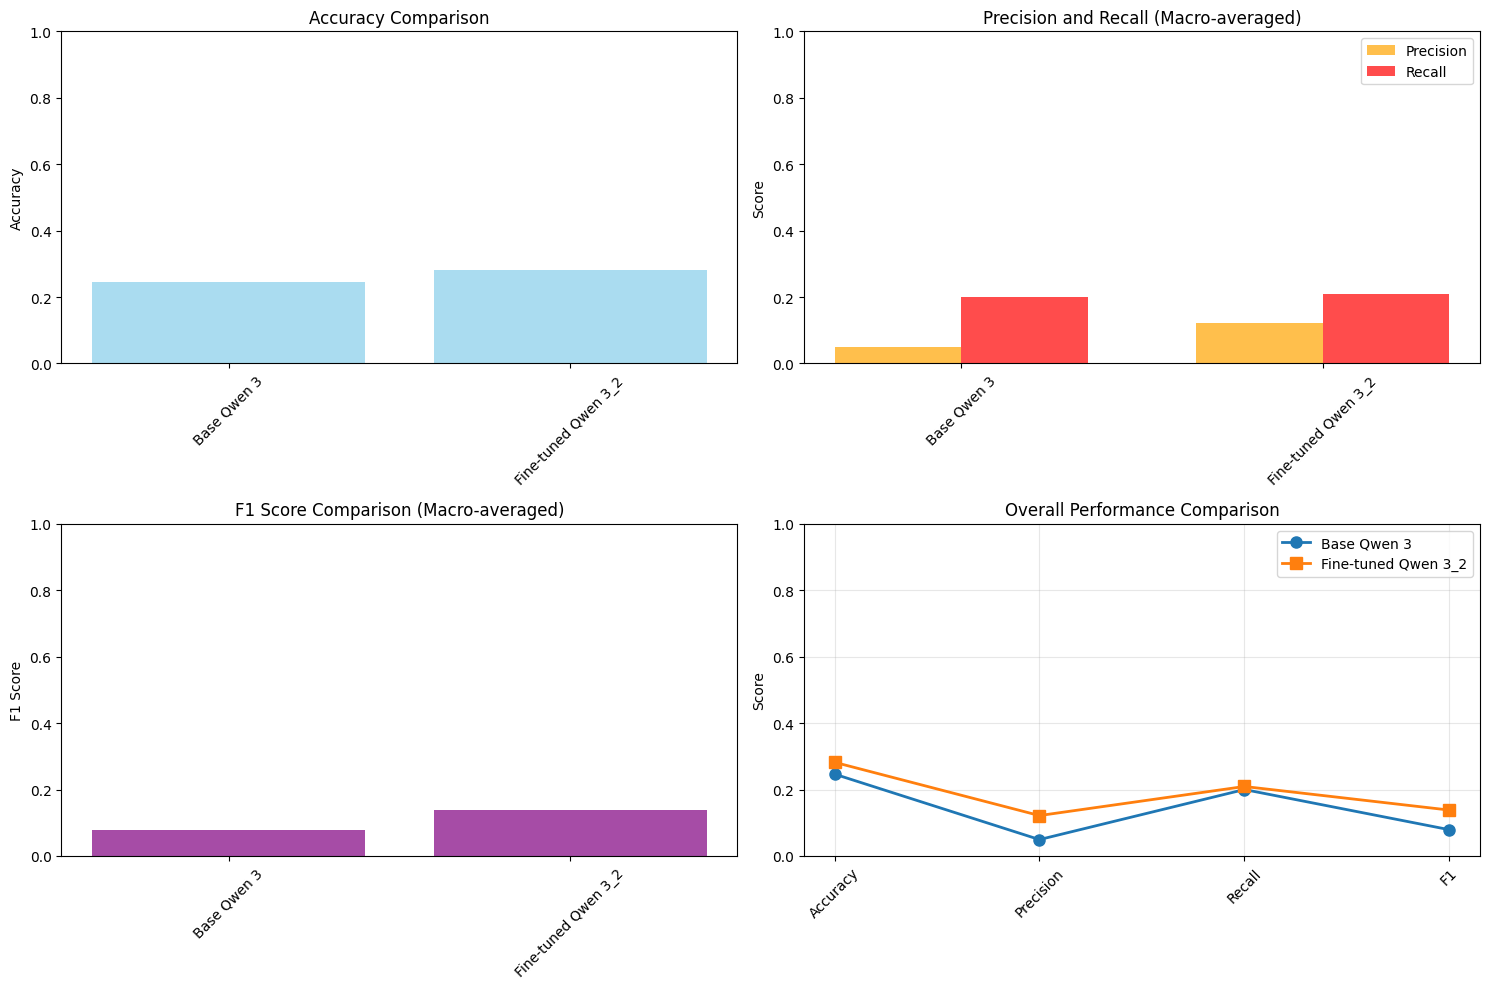

In [27]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import numpy as np

# Recalculate metrics properly
print("🔄 Recalculating metrics for single-label classification...")

def calculate_proper_metrics(predictions, true_labels):
    """Calculate proper metrics for single-label classification"""
    
    # Clean predictions to extract party names
    cleaned_predictions = []
    for pred in predictions:
        pred_clean = pred.strip().upper()
        found_orient = "UNKNOWN"
        for orient in orientation:
            if orient.upper() in pred_clean:
                found_orient = orient
                break
        cleaned_predictions.append(found_orient)
    
    # Calculate accuracy
    accuracy = accuracy_score(true_labels, cleaned_predictions)
    
    # Calculate per-class precision, recall, f1 (macro-averaged)
    precision, recall, f1, _ = precision_recall_fscore_support(
        true_labels, cleaned_predictions, average='macro', zero_division=0
    )
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

metrics_summary = {}
for model_name, preds in results.items():
    metrics = calculate_proper_metrics(preds, true_labels)
    metrics_summary[model_name] = metrics
    
    print(f"\n🤖 {model_name}:")
    print(f"   📊 Accuracy: {metrics['accuracy']:.3f}")
    print(f"   📊 Macro Precision: {metrics['precision']:.3f}")
    print(f"   📊 Macro Recall: {metrics['recall']:.3f}")
    print(f"   📊 Macro F1 Score: {metrics['f1']:.3f}")

# Create visualization with corrected metrics (3 plots instead of 4)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

model_names = list(results.keys())
accuracies = [metrics_summary[name]['accuracy'] for name in model_names]
precisions = [metrics_summary[name]['precision'] for name in model_names]
recalls = [metrics_summary[name]['recall'] for name in model_names]
f1_scores = [metrics_summary[name]['f1'] for name in model_names]

# Accuracy comparison
axes[0, 0].bar(model_names, accuracies, alpha=0.7, color='skyblue')
axes[0, 0].set_title('Accuracy Comparison')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].set_ylim(0, 1.0)

# Precision and Recall
x = np.arange(len(model_names))
width = 0.35
axes[0, 1].bar(x - width/2, precisions, width, label='Precision', alpha=0.7, color='orange')
axes[0, 1].bar(x + width/2, recalls, width, label='Recall', alpha=0.7, color='red')
axes[0, 1].set_title('Precision and Recall (Macro-averaged)')
axes[0, 1].set_ylabel('Score')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(model_names, rotation=45)
axes[0, 1].legend()
axes[0, 1].set_ylim(0, 1.0)

# F1 Score comparison
axes[1, 0].bar(model_names, f1_scores, alpha=0.7, color='purple')
axes[1, 0].set_title('F1 Score Comparison (Macro-averaged)')
axes[1, 0].set_ylabel('F1 Score')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].set_ylim(0, 1.0)

# Overall performance comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
base_scores = [accuracies[0], precisions[0], recalls[0], f1_scores[0]]
ft_scores = [accuracies[1], precisions[1], recalls[1], f1_scores[1]]

axes[1, 1].plot(metrics, base_scores, 'o-', label=model_names[0], linewidth=2, markersize=8)
axes[1, 1].plot(metrics, ft_scores, 's-', label=model_names[1], linewidth=2, markersize=8)
axes[1, 1].set_title('Overall Performance Comparison')
axes[1, 1].set_ylabel('Score')
axes[1, 1].legend()
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_ylim(0, 1.0)

plt.tight_layout()
plt.show()

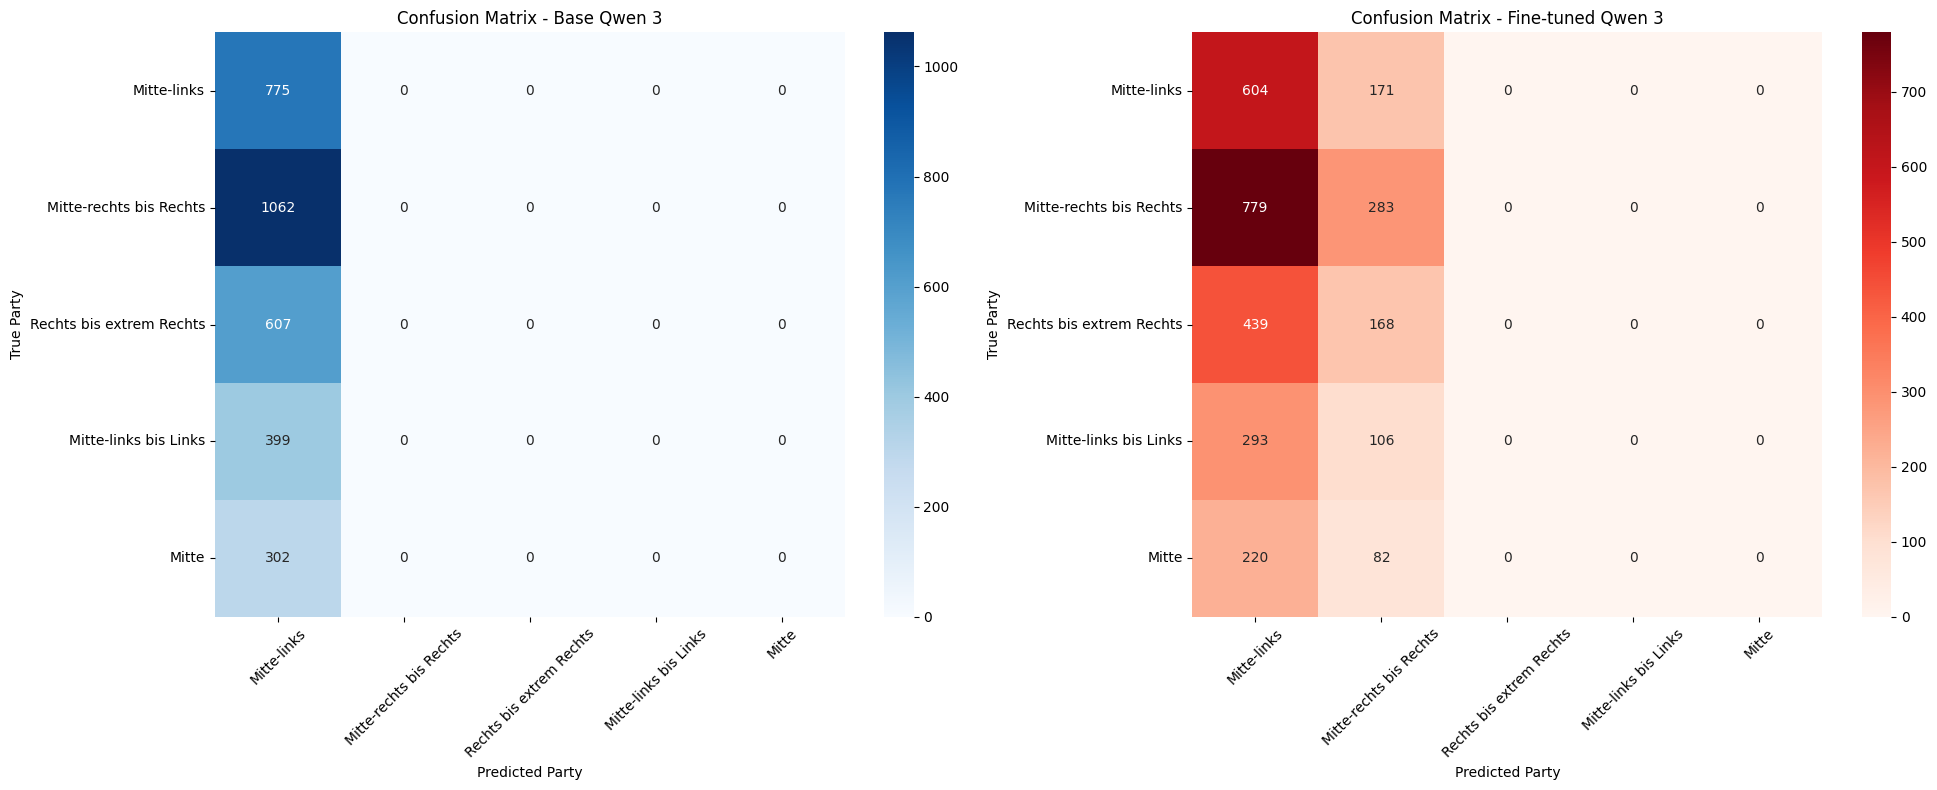

Base Model Accuracy: 0.246
Fine-tuned Model Accuracy: 0.282


In [28]:
#Include confusion matrices and classification reports
from sklearn.metrics import confusion_matrix

# Clean predictions for both models
base_cleaned_predictions = []
for pred in base_preds:
    pred_clean = pred.strip()
    found_orient = "UNKNOWN"
    for orient in orientation:
        if orient in pred_clean:
            found_orient = orient
            break
    base_cleaned_predictions.append(found_orient)

ft_cleaned_predictions = []
for pred in finetuned_preds:
    pred_clean = pred.strip()
    found_orient = "UNKNOWN"
    for orient in orientation:
        if orient in pred_clean:
            found_orient = orient
            break
    ft_cleaned_predictions.append(found_orient)

# Create confusion matrices
cm_base = confusion_matrix(true_labels, base_cleaned_predictions, labels=orientation)
cm_ft = confusion_matrix(true_labels, ft_cleaned_predictions, labels=orientation)

# Plot confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Base model confusion matrix
sns.heatmap(cm_base, 
            annot=True, 
            fmt='d',
            cmap='Blues',
            xticklabels=orientation,
            yticklabels=orientation,
            ax=axes[0])
axes[0].set_title('Confusion Matrix - Base Qwen 3')
axes[0].set_xlabel('Predicted Party')
axes[0].set_ylabel('True Party')
axes[0].tick_params(axis='x', rotation=45)

# Fine-tuned model confusion matrix
sns.heatmap(cm_ft, 
            annot=True, 
            fmt='d',
            cmap='Reds',
            xticklabels=orientation,
            yticklabels=orientation,
            ax=axes[1])
axes[1].set_title('Confusion Matrix - Fine-tuned Qwen 3')
axes[1].set_xlabel('Predicted Party')
axes[1].set_ylabel('True Party')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Print accuracies
base_accuracy = np.trace(cm_base) / np.sum(cm_base)
ft_accuracy = np.trace(cm_ft) / np.sum(cm_ft)
print(f"Base Model Accuracy: {base_accuracy:.3f}")
print(f"Fine-tuned Model Accuracy: {ft_accuracy:.3f}")
